<a href="https://github.com/arthurflor23/handwritten-text-recognition" target="_parent"><img src="https://img.shields.io/badge/Local-Environment-blue?style=for-the-badge&logo=python&color=2e7d32" alt="Local Environment"/></a>
<a href="https://ko-fi.com/arthurflor23" target="_parent"><img src="https://img.shields.io/badge/Ko--fi-F16061?style=for-the-badge&logo=ko-fi&logoColor=white" alt="Support on Ko-fi"/></a>


<a href="https://github.com/arthurflor23/handwritten-text-recognition" target="_parent">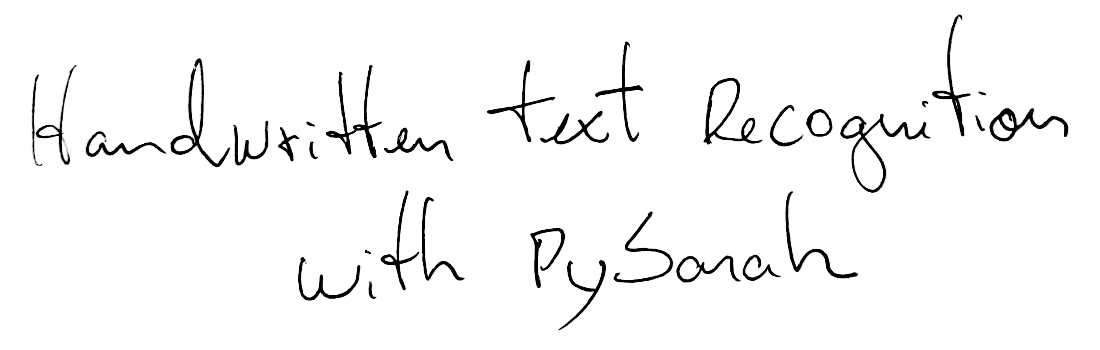</a>


# Handwritten Text Recognition with PySarah


## 1\. Introduction


In this tutorial, we'll explore [PySarah](https://github.com/arthurflor23/handwritten-text-recognition), a solution for Handwritten Text Recognition (HTR). We'll walk through setting up the environment, preparing the dataset, and then training, predicting, evaluating, and inspecting sample outputs. By the end, you'll have enough to apply the same steps to your own data.

We'll focus on the `recognition` workflow only, since training generative models is resource-intensive and falls outside the scope here. If you're curious, feel free to dig into the project's code. Before starting, take a quick look at the [README.md](https://github.com/arthurflor23/handwritten-text-recognition/blob/master/README.md) for the full documentation.


## 2\. Data Environment


In this section, we'll set up the data environment. We'll cover the supported datasets and how to add custom ones to the project.


### 2\.1\. Datasets


The project supports a wide range of datasets for handwritten text recognition. Several well-known datasets are already integrated and ready to use. The full list is available [here](https://github.com/arthurflor23/handwritten-text-recognition?tab=readme-ov-file#datasets).

To use them, place each dataset in the `datasets/` folder under its default name. That's all it takes for the project to pick them up during training and evaluation.

Custom datasets work the same way: follow the same folder structure and naming convention, and they'll be available alongside the built-in ones.


### 2\.2\. Font Prototypes

The project also supports font prototypes as input. TrueType (`.ttf`) fonts placed in the `fonts/` directory are processed by the `Dataset` class to create topological font graphs. These graph representations enhance character recognition and generative modeling.


## 3\. Local Environment Setup


A proper local setup is needed to use TensorFlow (with GPU acceleration if available on your system) and to access project files and datasets from your local computer drive. This section covers the configuration steps.


### 3\.1\. TensorFlow with GPU Acceleration


To check if your local environment has GPU support configured in TensorFlow, run the cell below. It will inspect available physical devices detected by TensorFlow, and you can also check `!nvidia-smi` if you have an NVIDIA GPU driver installed.


Execute the following code to inspect TensorFlow and GPU devices:


In [1]:
import tensorflow as tf

print(f"TensorFlow Version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU(s) Available ({len(gpus)}):")
    for gpu in gpus:
        print(f"  - {gpu}")
else:
    print("No GPU detected by TensorFlow. Running on CPU.")

# Optional: If you have an NVIDIA GPU and driver tools in PATH, uncomment below:
# !nvidia-smi

c:\Users\galig\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.15.903) or chardet (7.6.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


TensorFlow Version: 2.20.0
No GPU detected by TensorFlow. Running on CPU.


If the output shows available GPUs, TensorFlow is ready for GPU-accelerated computing. If running on CPU, the tutorial will still work properly, though training and inference will take longer.


### 3\.2\. Local Drive Working Directory


When running on a local computer, your files and datasets reside directly on your local drive (no Google Drive authentication or mounting required). Check your current working directory:


In [2]:
import os
from pathlib import Path

current_dir = Path.cwd()
print(f"Current working directory: {current_dir}")

Current working directory: d:\DL\handwritten-text-recognition


Ensure that the notebook is operating from the root directory of the `handwritten-text-recognition` repository so that `sarah` and the `datasets/` folder can be imported and accessed properly.


Set or navigate to the project directory on your local drive (adapt the path below to match your setup if needed):


In [3]:
import os
import sys
from pathlib import Path

# Adapt this path to your local project repository location if needed:
project_root = Path.cwd()

if project_root.name != 'handwritten-text-recognition':
    # Fallback path if notebook was launched from a different folder
    local_path = Path(r'd:\DL\handwritten-text-recognition')
    if local_path.exists():
        project_root = local_path

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root confirmed: {os.getcwd()}")

Project root confirmed: d:\DL\handwritten-text-recognition


Check the directory contents to confirm the project structure (`sarah`, `datasets`, `fonts`, `requirements.txt`):


In [4]:
import os

print("Project contents:")
for item in sorted(os.listdir('.')):
    prefix = "[DIR] " if os.path.isdir(item) else "      "
    print(f"{prefix}{item}")

Project contents:
      .editorconfig
[DIR] .git
[DIR] .github
      .gitignore
[DIR] .venv
      LICENSE
      README.md
[DIR] datasets
      download_datasets.py
[DIR] fonts
[DIR] outputs
      requirements.txt
[DIR] sarah
      tutorial.ipynb
      workflows.sh


Finally, install the project dependencies in your local Python/Jupyter environment:


In [5]:
%pip install -r requirements.txt

Ignoring tensorflow: markers 'platform_system == "Darwin"' don't match your environment
  Using cached opencv_python_headless-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached nvidia_cublas_cu12-12.9.2.10-py3-none-win_amd64.whl.metadata (1.8 kB)
  Using cached nvidia_cuda_cupti_cu12-12.9.79-py3-none-win_amd64.whl.metadata (1.8 kB)
  Using cached nvidia_cuda_nvcc_cu12-12.9.86-py3-none-win_amd64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.9.86-py3-none-win_amd64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_runtime_cu12-12.9.79-py3-none-win_amd64.whl.metadata (1.7 kB)
  Using cached nvidia_cudnn_cu12-9.27.0.42-py3-none-win_amd64.whl.metadata (1.9 kB)
  Using cached nvidia_cufft_cu12-11.4.1.4-py3-none-win_amd64.whl.metadata (1.8 kB)
  Using cached nvidia_curand_cu12-10.3.10.19-py3-none-win_amd64.whl.metadata (1.7 kB)
  Using cached nvidia_cusolver_cu12-11.7.5.82-py3-none-win_amd64.whl.metadata (1.9 kB)
  Using cached nvidia_cusparse_cu12-12.5.10.65-py3

ERROR: Cannot install tensorflow[and-cuda]==2.20.0 and tensorflow[and-cuda]==2.21.0 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


## 4\. Dataset Class


First, a quick note on the `Tokenizer` class. It handles encoding and decoding texts for the models, and it can be reused across datasets (it updates automatically). Before building the dataset, we check if a tokenizer and its MLflow run context already exist. This lets the `Dataset` class load the tokenizer, and the `Compose` class load matching model weights.


The `Dataset` class manages data source loading, partitioning, and font graph processing. The project supports 14 integrated datasets (`washington`, `mnist`, `saintgall`, `parzival`, `cvl-digits`, `emnist`, `bentham`, `cvl-database`, `rimes`, `orand-car`, `iam`, etc.).

Choose any source from `DATASET_CONFIGS` below to initialize and explore it:


In [6]:
from sarah import Dataset
from sarah import Compose

# Preset configurations for all supported dataset sources
DATASET_CONFIGS = {
    'washington':   {'text_level': 'line', 'image_shape': (64, 1024, 1), 'desc': 'Washington handwriting database (English)'},
    'mnist':        {'text_level': 'char', 'image_shape': (28, 28, 1),   'desc': 'MNIST isolated handwritten digits (0-9)'},
    'saintgall':    {'text_level': 'line', 'image_shape': (64, 1024, 1), 'desc': 'Saint Gall medieval manuscript (Latin)'},
    'parzival':     {'text_level': 'line', 'image_shape': (64, 1024, 1), 'desc': 'Parzival medieval manuscript (Middle High German)'},
    'cvl-digits':   {'text_level': 'line', 'image_shape': (64, 1024, 1), 'desc': 'CVL Digits string database'},
    'emnist':       {'text_level': 'char', 'image_shape': (28, 28, 1),   'desc': 'Extended MNIST handwritten characters'},
    'bentham':      {'text_level': 'line', 'image_shape': (64, 1024, 1), 'desc': 'Bentham manuscripts collection (English)'},
    'cvl-database': {'text_level': 'line', 'image_shape': (64, 1024, 1), 'desc': 'CVL Database of handwritten words and lines'},
    'rimes':        {'text_level': 'line', 'image_shape': (64, 1024, 1), 'desc': 'RIMES French handwriting database'},
    'orand-car-a':  {'text_level': 'line', 'image_shape': (64, 1024, 1), 'desc': 'ORAND-CAR digit strings (subset A)'},
    'orand-car-b':  {'text_level': 'line', 'image_shape': (64, 1024, 1), 'desc': 'ORAND-CAR digit strings (subset B)'},
    'iam':          {'text_level': 'line', 'image_shape': (64, 1024, 1), 'desc': 'IAM Handwriting database (English)'},
    'bressay':      {'text_level': 'line', 'image_shape': (64, 1024, 1), 'desc': 'BRESSAY historical document database'},
    'all-in-one':   {'text_level': 'line', 'image_shape': (64, 1024, 1), 'desc': 'Combined multi-source dataset'}
}

# Select any source to use (e.g. 'washington', 'mnist', 'saintgall', 'parzival', 'cvl-digits', etc.):
source = 'washington'

config = DATASET_CONFIGS.get(source, {'text_level': 'line', 'image_shape': (64, 1024, 1)})
text_level = config['text_level']
image_shape = config['image_shape']
seed = 42
recognition = 'flor'

tokenizer, run_context = Compose.get_tokenizer(recognition=recognition, recognition_run_id=None)

# Dataset loads images, labels, and font prototypes from fonts/
dataset = Dataset(source=source,
                  text_level=text_level,
                  image_shape=image_shape,
                  fonts_path='fonts',
                  tokenizer=tokenizer,
                  seed=seed)
dataset

c:\Users\galig\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                              Dataset                               
--------------------------------------------------------------------
source                   : washington
text_level               : line
image_shape              : (64, 1024, 1)
char_width               : -
training_ratio           : -
validation_ratio         : -
test_ratio               : -
illumination             : -
binarization             : -
lazy_mode                : False
seed                     : 42
--------------------------------------------------------------------
training_data            : 325
validation_data          : 168
test_data                : 163
total_data               : 656
--------------------------------------------------------------------
multigrams               : 0
--------------------------------------------------------------------
fonts                    : 100
                             Tokenizer                              
------------------------------------------------------

**Note:** To add a custom source, create a new file (`<custom_source>.py`) in `sarah/data/source/` following the same pattern as the existing ones. Then pass `source='<custom_source>'` when creating the Dataset.


## 5\. Augmentor Class


The `Augmentor` class applies image transformations for data augmentation. Each parameter takes a tuple where the first value is the probability of applying the transformation, and the remaining values are its specific settings. Adjust them to fit your needs.


In [7]:
from sarah import Augmentor


augmentor = Augmentor(mixup=None,
                      erode=(0.33, 3),
                      dilate=None,
                      elastic=None,
                      perspective=(0.66, 0.3),
                      shear=(0.33, 0.3),
                      rotate=(0.33, 0.3),
                      scale=(0.33, 0.1),
                      shift_y=None,
                      shift_x=None,
                      salt_and_pepper=None,
                      gaussian_noise=None,
                      gaussian_blur=None,
                      seed=seed)
augmentor

                             Augmentor                              
--------------------------------------------------------------------
mixup                    : -
erode                    : (0.33, 3)
dilate                   : -
elastic                  : -
perspective              : (0.66, 0.3)
shear                    : (0.33, 0.3)
rotate                   : (0.33, 0.3)
scale                    : (0.33, 0.1)
shift_y                  : -
shift_x                  : -
salt_and_pepper          : -
gaussian_noise           : -
gaussian_blur            : -
seed                     : 42

## 6\. Compose Class


The `Compose` class is the core of the project — it manages the recognition model, synthesis model, or a combination of both, along with MLflow tracking. It also handles the common pipelines (compile, fit, predict, evaluate, and so on). Once created, the model is compiled, optionally with a run context to resume training from a previous run. For this tutorial, we'll use `flor` as the recognition model.


In [ ]:
from sarah import Compose


compose = Compose(recognition=recognition,
                  image_shape=image_shape,
                  tokenizer=dataset.tokenizer,
                  seed=seed)

compose.compile(learning_rate=1e-3, run_context=run_context)
compose

# compose.model.recognition.summary()


                         Run context (base)                         
--------------------------------------------------------------------
experiment_id            : 0
experiment_name          : Default
run_id                   : 34f349f1d66745688e63e0a13dbb3a3c
run_name                 : 2026-10-07 11:24:30
--------------------------------------------------------------------


                              Compose                               
                          RecognitionModel                          
--------------------------------------------------------------------
Module                   : flor
Model                    : recognition
--------------------------------------------------------------------
Total params             : 1,580,763
Trainable params         : 1,579,883
Non-trainable params     : 880
Size (MB)                : 6.03

: 

**Note:** Similar to custom sources, to add a custom model create a new file (`<custom_model>.py`) in `sarah/models/{synthesis,recognition}/` following the same pattern as the existing networks. Then pass `<custom_model>` to the `{synthesis, recognition}` parameter when creating the `Compose` object.


### 6\.1\. Model Training


Now let's train the recognition model using the dataset and augmentor defined earlier:


In [ ]:
# For full GPU training, set epochs = 1000.
# For local CPU testing/tutorial, keep epochs small (e.g. 2) to prevent kernel timeouts.
epochs = 2
batch_size = 8
plateau_factor = 0.1
plateau_cooldown = 0
plateau_patience = 60
patience = 100

training_gen, training_steps = dataset.get_generator(data_partition='training',
                                                     batch_size=batch_size,
                                                     augmentor=augmentor,
                                                     shuffle=True)
validation_gen, validation_steps = dataset.get_generator(data_partition='validation',
                                                         batch_size=batch_size)

compose.fit(training_gen=training_gen,
            training_steps=training_steps,
            validation_gen=validation_gen,
            validation_steps=validation_steps,
            plateau_factor=plateau_factor,
            plateau_cooldown=plateau_cooldown,
            plateau_patience=plateau_patience,
            patience=patience,
            epochs=epochs)


Epoch 1/2



1. **Data generators:** The `get_generator` method of the `Dataset` class was used to generate data generators for the training and validation partitions. Thus, the `data_partition` parameter specify the corresponding partition to be used. The `batch_size` determines the number of samples per batch. The `augmentor` is used to apply augmentation techniques to the data.

2. **Model fitting:** The `fit` method of the `Compose` class is used to train the model. The `epochs` parameter specifies the maximum number of training epochs. The `training_gen` and `validation_gen` parameters accept the data generator, where the `training_steps` and `validation_steps` specify the number of steps per epoch for training and validation, respectively.


Running this will start training. Feel free to tune the parameters to fit your setup.


### 6\.2\. Model Prediction


With the model trained, let's use it to predict on the test set:


In [ ]:
top_paths = 1
beam_width = 32

test_gen, test_steps = dataset.get_generator(data_partition='test',
                                             batch_size=batch_size)

predictions, probabilities = compose.predict_recognition(x=test_gen,
                                                         steps=test_steps,
                                                         top_paths=top_paths,
                                                         beam_width=beam_width,
                                                         ctc_decode=True,
                                                         token_decode=True,
                                                         verbose=1)

Breaking it down:

1. **Test Generator:** The `get_generator` method of the `Dataset` class was used to generate data generators for the test partition. Thus, the `data_partition` parameter specifies the test subset, and the `batch_size` parameter determines the number of samples per batch.

2. **Predictions:** The `predict_recognition` method of the `Compose` class is used to make predictions on the test data, specifically for recognition task. The `x` parameter accepts the data generator, where the `steps` parameter specifies the number of steps for the data subset.


The outputs are stored in `predictions` and `probabilities`, both will be used in the evaluation step that follows.


### 6\.3\. Model Evaluation


Now let's evaluate the model by comparing its predictions against the ground truth. Reuse the test generator and the predictions from the previous step:


In [ ]:
source_gen, source_steps = dataset.get_generator(data_partition='test',
                                                 batch_size=batch_size,
                                                 batch_encoded=False)

metrics, evaluations = compose.evaluate_recognition(x=predictions,
                                                    y=source_gen,
                                                    steps=source_steps,
                                                    probabilities=probabilities,
                                                    verbose=1)
metrics

**Note:** Evaluation needs raw, unencoded data. For recognition, this means plain string texts, controlled by the `batch_encoded=False` flag. The `evaluate_recognition` method computes the metrics and returns a JSON with the per-sample evaluations. Use the `json` module to pretty-print it:


In [ ]:
import json

print(json.dumps(evaluations['data'], indent=4, ensure_ascii=False))

### 6\.4\. MLflow Context


Some information is logged automatically during and after training, but additional context needs to be saved manually:


In [ ]:
compose.save_context(dataset=dataset,
                     augmentor=augmentor,
                     model=compose.model,
                     metrics=metrics,
                     evaluations=evaluations,
                     new_context=True)

Once the `save_context` method is called, MLflow stores everything in the artifacts path, where it can be browsed from the MLflow Dashboard (`mlflow ui`).


## 7\. Samples


Finally, let's visualize a few test samples to compare the ground truth against the model's predictions. A quick way to get a sense of how the model behaves on individual examples.


In [ ]:
import matplotlib.pyplot as plt


src_gen, _ = dataset.get_generator(data_partition='test',
                                   batch_size=batch_size,
                                   batch_encoded=False,
                                   batch_processing=False,
                                   batch_scale=False,
                                   augmentor=None,
                                   shuffle=False)

enc_gen, _ = dataset.get_generator(data_partition='test',
                                   batch_size=batch_size,
                                   batch_encoded=True,
                                   batch_processing=False,
                                   batch_scale=False,
                                   augmentor=None,
                                   shuffle=False)

step = 1
for i in range(step, step + 1):
    _, y_src = next(src_gen)
    img_src, txt_src, wri_src = y_src[:3]

    _, y_enc = next(enc_gen)
    img_enc = y_enc[0]

    for j in range(len(img_src)):
        print('Path image')
        print(img_src[j], '\n')

        print('Source writer')
        print(wri_src[j], '\n')

        print('Source text')
        print(txt_src[j], '\n')

        print('Predicted text')
        print(predictions[i * j][0], '\n')

        print('Image')
        plt.figure(figsize=(6, 3))
        plt.imshow(img_enc[j], cmap='gray')
        plt.axis('off')
        plt.show()
        print('-' * 68, '\n')